In [1]:
import numpy as np
import matplotlib.pyplot as plt
from grid_cells.random_walk import generate_bat_flight
from grid_cells.attractor_networks import HeadDirection
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"
from grid_cells.attractor_networks import HeadDirection

import tqdm
import os

DATA_DIR = "../simulation_data"
PLOTS_DIR = "../plots"

[0.00462077]
Ran warm up for 132 steps


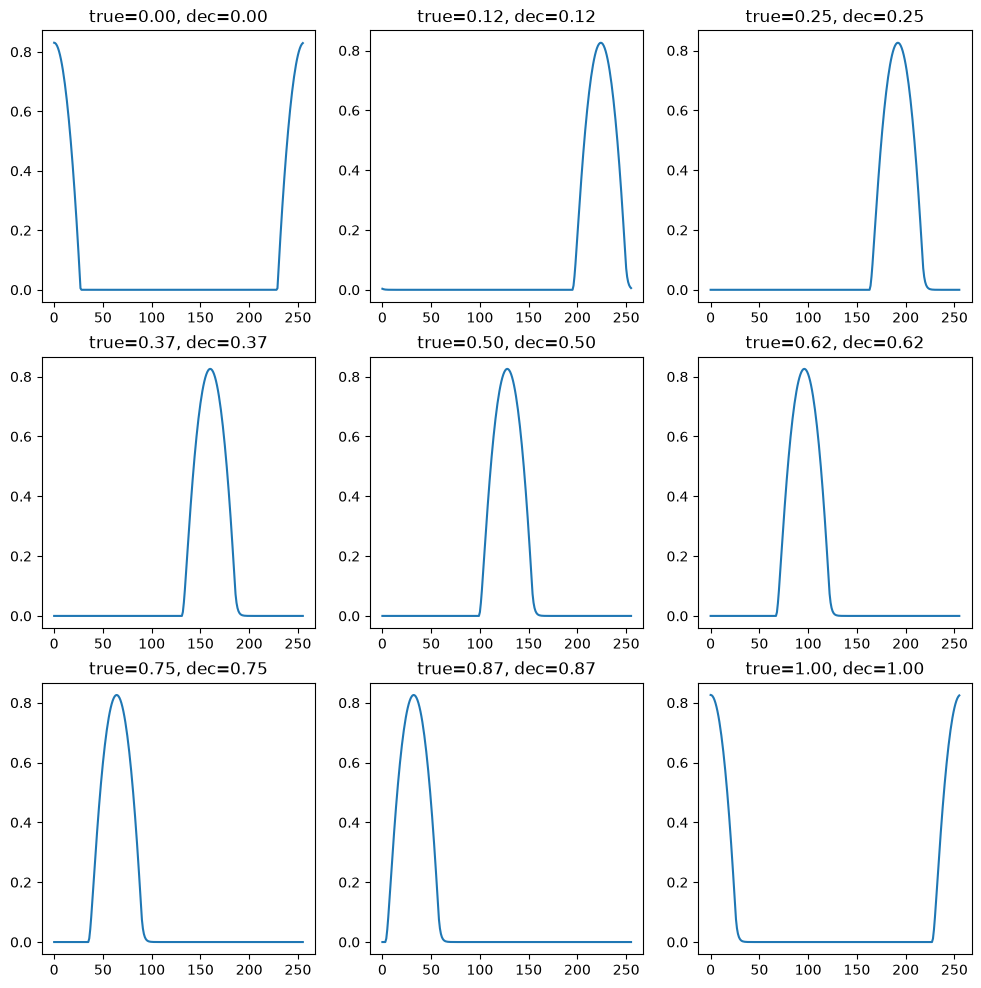

In [2]:
dt = 0.5e-3
n = 256
n_min_plots = 9

net = HeadDirection(
    n=(n), dt=dt, use_single_bump=True
)
net.s = net.encode_orientation(0)
net.warm_up()
ncols = np.int64(np.ceil(np.sqrt(n_min_plots)))
nrows = np.int64(np.ceil(n_min_plots / ncols))
n_plots = nrows * ncols
fig, ax = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
ax = ax.flatten()
phi = 0
omega = 5
omega_max = 5
duration = int(0.02 / dt)
n_steps = int((2 * np.pi) / omega / dt)
records = np.linspace(0, n_steps - 1, n_plots, dtype=int)
plot_counter = 0
time = 0


for step_iter in range(n_steps):
    if step_iter == records[plot_counter]:
        decoded_angle = net.decode_orientation()
        ax[plot_counter].plot(net.s)
        ax[plot_counter].set_title(f"true={phi/(2*np.pi):.2f}, dec={decoded_angle[0]/(2*np.pi):.2f}")
        plot_counter += 1
    net.step(np.array([omega]))
    phi += omega * dt
    time += dt

In [3]:

## Simulation parameters:
n_min_plots = 10
T = 200
dt = 0.5e-3
n = 256
net = HeadDirection(
    n=(n,), dt=dt, use_single_bump=True
)
net.warm_up()
bat_flight = generate_bat_flight(T=T, dt=dt)
n_steps = bat_flight["pos"].shape[0]

recording = net.run_simulation(bat_flight["dir_vel"][:,0][:,np.newaxis])



[0.00462077]
Ran warm up for 357 steps


Running Simulation Steps: 100%|██████████| 400000/400000 [00:26<00:00, 14916.79it/s]


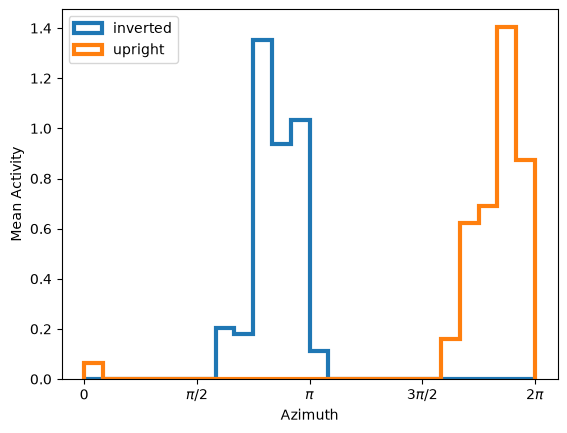

In [21]:
from grid_cells.plot_tools import activity_map

cell_index = 5
inverted = bat_flight["inverted"]
azimuth = bat_flight["dir_sphere"][:,0] + np.pi
bins = np.linspace(0,2*np.pi,25)

cell_recording = recording["cell_recording"][:, cell_index]
fig, ax = plt.subplots()#subplot_kw={'projection': 'polar'}, layout='constrained')
plt.hist(azimuth[inverted],weights=cell_recording[inverted],bins = bins,label="inverted",density=True,histtype="step",linewidth=3)
plt.hist(azimuth[~inverted],weights=cell_recording[~inverted],bins = bins,label="upright",density=True,histtype="step",linewidth=3)
ax.set_xlabel("Azimuth")
ax.set_ylabel("Mean Activity")

ax.set_xticks(np.arange(0, 2.5, 0.5) * np.pi)
ax.set_xticklabels([r"0", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"2$\pi$"])
ax.legend(loc="best")
fig.savefig(os.path.join(PLOTS_DIR, "bat_flight_inverted_pure_cell.png"))